Using dataset path: /kaggle/input/datasets/mobeenfatimah/stroke-risk-prediction-dataset/stroke_risk_prediction_dataset.csv
Shape: (50000, 40)

--- Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 40 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Patient_ID                    50000 non-null  int64  
 1   Age                           49781 non-null  float64
 2   Gender                        50000 non-null  object 
 3   Country                       50000 non-null  object 
 4   Height_cm                     48475 non-null  float64
 5   Weight_kg                     48477 non-null  float64
 6   BMI                           50000 non-null  float64
 7   Blood_Pressure_Systolic       50000 non-null  int64  
 8   Blood_Pressure_Diastolic      50000 non-null  int64  
 9   Heart_Rate                    50000 non-null  int64  
 10  Blood_Glucose         

/tmp/ipykernel_58/4146416400.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Stroke_Risk", order=["Low", "Moderate", "High"],


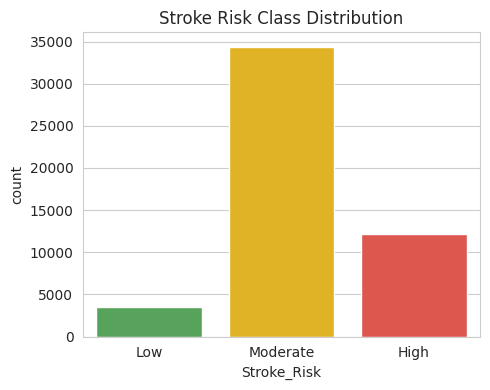

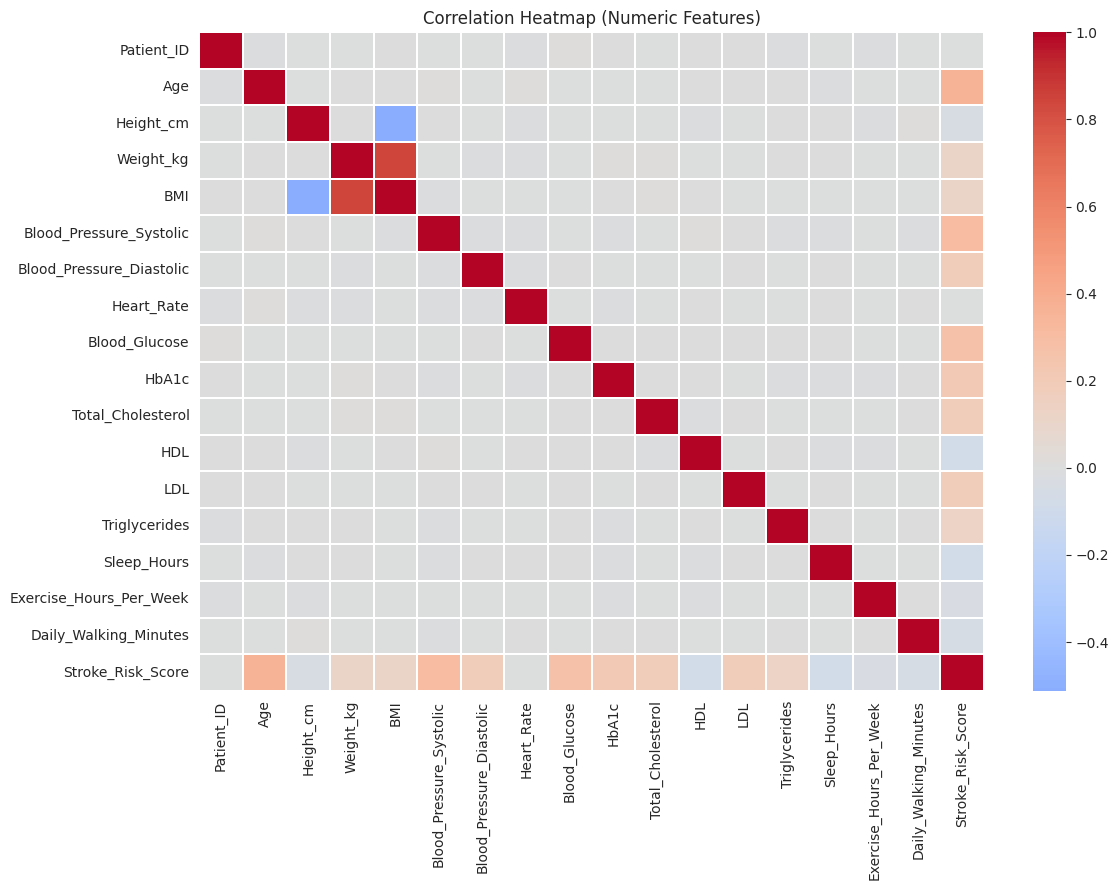


Accuracy : 0.7959
Macro F1 : 0.5750

Classification report:
              precision    recall  f1-score   support

        High       0.92      0.44      0.60      2422
         Low       0.99      0.15      0.26       703
    Moderate       0.78      0.99      0.87      6875

    accuracy                           0.80     10000
   macro avg       0.90      0.53      0.58     10000
weighted avg       0.83      0.80      0.76     10000



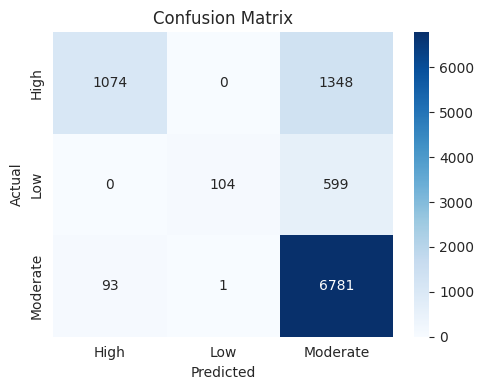

/tmp/ipykernel_58/4146416400.py:151: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette="viridis")


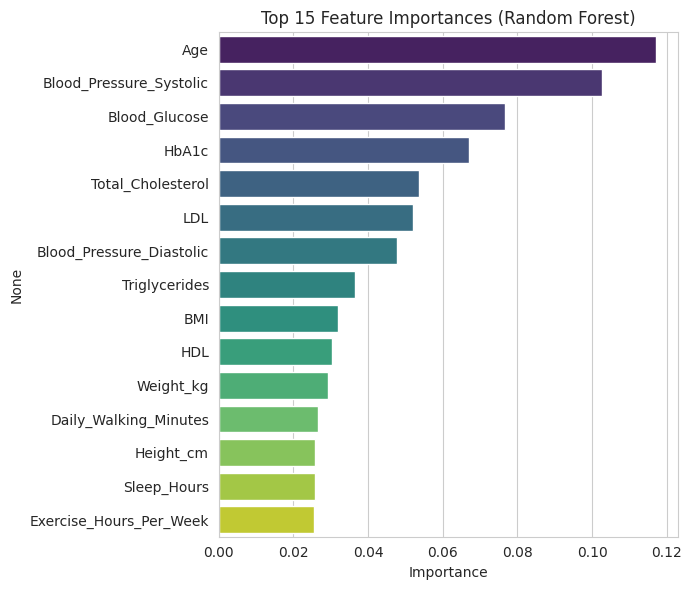


Done. Charts saved as PNG files in the working directory.


In [1]:
"""
Stroke Risk Prediction — Kaggle Notebook Script
=================================================
Dataset: stroke_risk_prediction_dataset.csv (50,000 rows x 40 cols)

Paste this into a Kaggle notebook cell (or split into multiple cells).
Just make sure the CSV path matches your Kaggle input folder, e.g.:
    /kaggle/input/<dataset-name>/stroke_risk_prediction_dataset.csv
"""

import pandas as pd   # data load ও numeric operation-এর জন্য csv Data fram copy korar janno used kora hoy
import numpy as np    # data load ও numeric operation-এর জন্য
import matplotlib.pyplot as plt   # data load ও numeric operation-এর জন্য
import seaborn as sns 

from sklearn.model_selection import train_test_split  # data ভাগ করা
from sklearn.preprocessing import LabelEncoder        # text কে number-এ কনভার্ট
from sklearn.impute import SimpleImputer     # missing value ভরাট
from sklearn.ensemble import RandomForestClassifier  # মূল ML model
from sklearn.metrics import (  
    accuracy_score, classification_report, confusion_matrix, f1_score
)

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

# -------------------------------------------------------------------
# 1. LOAD DATA
# -------------------------------------------------------------------
DATA_PATH = "/kaggle/input/datasets/mobeenfatimah/stroke-risk-prediction-dataset/stroke_risk_prediction_dataset.csv"
print("Using dataset path:", DATA_PATH)
df = pd.read_csv(DATA_PATH)      # আপনার CSV-এর exact path থেকে pd.read_csv() দিয়ে data load হচ্ছে

print("Shape:", df.shape)     # দিয়ে quick check — কত row/column আছে, প্রথম কয়েকটা row কেমন দেখতে
df.head()

# -------------------------------------------------------------------
# 2. QUICK EDA # Exploratory Data Analysis
# -------------------------------------------------------------------
print("\n--- Info ---")
df.info()  # প্রতিটা column-এর data type ও non-null count

print("\n--- Missing values (top 10) ---")
print(df.isnull().sum().sort_values(ascending=False).head(10))   # Missing value গুলো সবচেয়ে বেশি কোন column-এ, সেটা sort করে দেখানো

print("\n--- Target distribution ---")
print(df["Stroke_Risk"].value_counts()) #Stroke_Risk (target) column-এর প্রতিটা class-এ কতগুলো করে row আছে সেটা count করা, তারপর bar chart বানানো — এতে বোঝা যায় data imbalanced কিনা

plt.figure(figsize=(5, 4))
sns.countplot(data=df, x="Stroke_Risk", order=["Low", "Moderate", "High"],
              palette=["#4CAF50", "#FFC107", "#F44336"])
plt.title("Stroke Risk Class Distribution")
plt.tight_layout()
plt.savefig("target_distribution.png", dpi=120)
plt.show()

# Correlation heatmap of numeric features #সব numeric column-এর মধ্যে correlation বের করে heatmap আঁকা — কোন দুইটা feature একসাথে বাড়ে/কমে সেটা দেখার জন্য
num_cols = df.select_dtypes(include=np.number).columns.tolist()
plt.figure(figsize=(12, 9))
sns.heatmap(df[num_cols].corr(), cmap="coolwarm", center=0, linewidths=0.3)
plt.title("Correlation Heatmap (Numeric Features)")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=120)
plt.show()

# -------------------------------------------------------------------
# 3. HANDLE LEAKAGE COLUMNS  (IMPORTANT!)
# -------------------------------------------------------------------
# Stroke_Risk_Score, AI_Health_Recommendation and Doctor_Consultation_Needed
# are all DERIVED directly from Stroke_Risk (they perfectly / near-perfectly
# encode the label). Training on them gives fake 99-100% "accuracy" that
# means nothing. We drop them so the model learns from real health signals.

#Stroke_Risk_Score, AI_Health_Recommendation,Doctor_Consultation_Needed — এই কলামগুলো
# 
LEAKY_COLS = ["Stroke_Risk_Score", "AI_Health_Recommendation",
              "Doctor_Consultation_Needed", "Patient_ID"]
model_df = df.drop(columns=LEAKY_COLS)

target = "Stroke_Risk"
X = model_df.drop(columns=[target]) # target k remove korar janno using ( jatu jula thakbe setar janno 'target1';'target2')  
y = model_df[target]    # atary sudu target coloumn k niye asbo.

# -------------------------------------------------------------------
# 4. PREPROCESSING
# -------------------------------------------------------------------
cat_cols = X.select_dtypes(include="object").columns.tolist()
num_cols = X.select_dtypes(include=np.number).columns.tolist()

# Impute missing numeric values with median
num_imputer = SimpleImputer(strategy="median")
X[num_cols] = num_imputer.fit_transform(X[num_cols])

# Label-encode categorical columns
encoders = {}
for c in cat_cols:
    le = LabelEncoder()
    X[c] = le.fit_transform(X[c].astype(str))
    encoders[c] = le

y_le = LabelEncoder()
y_enc = y_le.fit_transform(y)  # High/Low/Moderate -> 0/1/2

# -------------------------------------------------------------------
# 5. TRAIN / TEST SPLIT
# -------------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)

# -------------------------------------------------------------------
# 6. TRAIN MODEL
# -------------------------------------------------------------------
model = RandomForestClassifier(
    n_estimators=300, max_depth=None, class_weight="balanced",
    random_state=42, n_jobs=-1
)
model.fit(X_train, y_train)

# -------------------------------------------------------------------
# 7. EVALUATE
# -------------------------------------------------------------------
y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="macro")
print(f"\nAccuracy : {acc:.4f}")
print(f"Macro F1 : {f1:.4f}\n")

print("Classification report:")
print(classification_report(y_test, y_pred, target_names=y_le.classes_))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=y_le.classes_, yticklabels=y_le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=120)
plt.show()

# -------------------------------------------------------------------
# 8. FEATURE IMPORTANCE
# -------------------------------------------------------------------
importances = pd.Series(model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(7, 6))
sns.barplot(x=importances.values, y=importances.index, palette="viridis")
plt.title("Top 15 Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=120)
plt.show()

print("\nDone. Charts saved as PNG files in the working directory.")